In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
# --- TASK 01: DATASET AUDIT ---
# Identify missing values and outliers before cleaning
file_path = "Online Retail.xlsx"  # Ensure this matches your local path
df = pd.read_excel(file_path)

print("--- Step 1: Dataset Audit ---")
print(f"Initial Shape: {df.shape}")
print("\nMissing Values per Column:")
print(df.isnull().sum())  # Identifying missing data for audit [cite: 132]
print("\nDescriptive Statistics (Check for Outliers):")
print(df[["Quantity", "UnitPrice"]].describe())

--- Step 1: Dataset Audit ---
Initial Shape: (541909, 8)

Missing Values per Column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Descriptive Statistics (Check for Outliers):
            Quantity      UnitPrice
count  541909.000000  541909.000000
mean        9.552250       4.611114
std       218.081158      96.759853
min    -80995.000000  -11062.060000
25%         1.000000       1.250000
50%         3.000000       2.080000
75%        10.000000       4.130000
max     80995.000000   38970.000000


In [4]:
# --- TASK 02: DATA QUALITY & CLEANING ---
# Justification: We remove missing CustomerIDs because we cannot track repeat behavior
# for anonymous users. We remove 'C' invoices to exclude returns.
df_cleaned = df.dropna(subset=["CustomerID"])  # Remove missing IDs 
df_cleaned = df_cleaned[
    ~df_cleaned["InvoiceNo"].astype(str).str.startswith("C")
]  # Remove cancellations
df_cleaned = df_cleaned[
    (df_cleaned["Quantity"] > 0) & (df_cleaned["UnitPrice"] > 0)
]  # Filter non-positives
df_cleaned["TotalSum"] = df_cleaned["Quantity"] * df_cleaned["UnitPrice"]
df_cleaned["InvoiceDate"] = pd.to_datetime(df_cleaned["InvoiceDate"])
print(f"\nShape after cleaning: {df_cleaned.shape}")


Shape after cleaning: (397884, 9)


In [5]:
# --- TASK 03: BUILD RFM SEGMENTATION ---
# 1. Calculate RFM Metrics
snapshot_date = df_cleaned["InvoiceDate"].max() + pd.Timedelta(days=1)
rfm = (
    df_cleaned.groupby("CustomerID")
    .agg(
        {
            "InvoiceDate": lambda x: (snapshot_date - x.max()).days,  # Recency
            "InvoiceNo": "nunique",  # Frequency
            "TotalSum": "sum",  # Monetary
        }
    )
    .reset_index()
)

rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

# 2. Assign RFM Scores (1-5) using Quantiles
# Note: For Recency, a lower value is better, so labels are reversed
rfm["R_Score"] = pd.qcut(rfm["Recency"], q=5, labels=[5, 4, 3, 2, 1])
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5]
)
rfm["M_Score"] = pd.qcut(rfm["Monetary"], q=5, labels=[1, 2, 3, 4, 5])


# 3. Create Segment Labels based on Slide Logic
def label_segment(row):
    r, f, m = int(row["R_Score"]), int(row["F_Score"]), int(row["M_Score"])
    if r >= 4 and f >= 4 and m >= 4:
        return "Champion"
    elif r >= 3 and f >= 3:
        return "Loyal"
    elif r <= 2:
        return "At Risk"
    else:
        return "Potential"


rfm["Label"] = rfm.apply(label_segment, axis=1)


--- CEO SEGMENTATION REPORT ---
          Recency Frequency Monetary      
             mean      mean     mean count
Label                                     
At Risk     193.4       2.0    772.8  1708
Champion     12.9      11.1   6038.8   962
Loyal        34.1       3.7   1477.1   998
Potential    36.8       1.2    459.7   670

--- RECOMMENDED CAMPAIGN STRATEGIES ---
Champion: VIP & Loyalty: Exclusive perks and early access.
Loyal: Retention: Get upsell offers and brand advocacy programs.
At Risk: Reactivation: Win back with targeted, time-sensitive incentives.
Potential: Nurture: Welcome sequences and first-purchase follow-ups.


/var/folders/91/v0zrf7r10db595g6bmjsfn440000gn/T/ipykernel_13681/1960456618.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


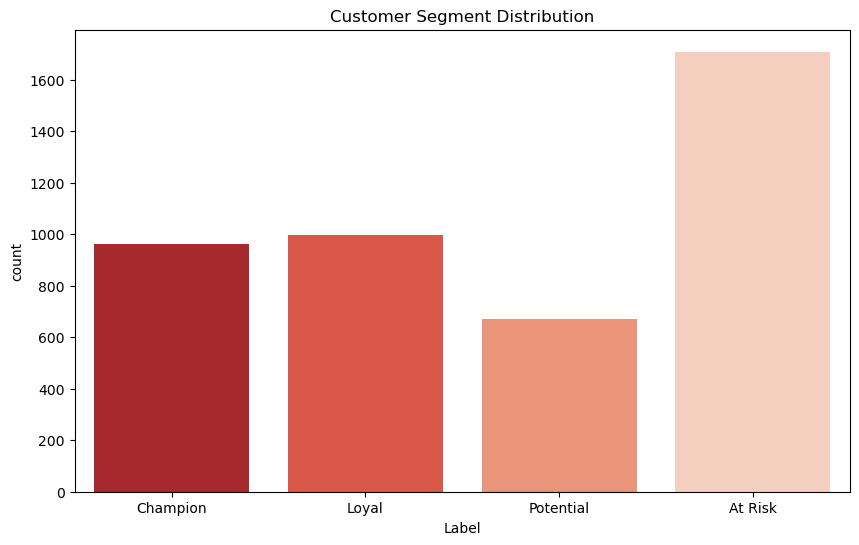

In [ ]:
# --- TASK 04: INSIGHTS AND ACTIONS FOR THE CEO ---
# Create a summary for executive presentation
ceo_report = (
    rfm.groupby("Label")
    .agg({"Recency": "mean", "Frequency": "mean", "Monetary": ["mean", "count"]})
    .round(1)
)

print("\n--- CEO SEGMENTATION REPORT ---")
print(ceo_report)

# Add Campaign Strategy based on Lecture
strategies = {
    "Champion": "VIP & Loyalty: Exclusive perks and early access.",
    "Loyal": "Retention: Get upsell offers and brand advocacy programs.",
    "At Risk": "Reactivation: Win back with targeted, time-sensitive incentives.",
    "Potential": "Nurture: Welcome sequences and first-purchase follow-ups.",
}

print("\n--- RECOMMENDED CAMPAIGN STRATEGIES ---")
for label, action in strategies.items():
    print(f"{label}: {action}")

# Visualizing Segment Distribution for Slides
plt.figure(figsize=(10, 6))
sns.countplot(
    x="Label",
    data=rfm,
    palette="Reds_r",
    order=["Champion", "Loyal", "Potential", "At Risk"],
)
plt.title("Customer Segment Distribution")
# plt.savefig("ceo_segment_distribution.png")
plt.show()